# Football Data Analysis - Statistical Analysis

## Overview
Analisis statistik komprehensif untuk dataset football yang sudah dibersihkan.

## Contents
1. Data Loading & Overview
2. Descriptive Statistics  
3. Distribution Analysis
4. Correlation Analysis
5. Statistical Tests
6. Advanced Group Analysis

---

## 1. Setup and Data Loading

In [44]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
np.random.seed(42)


In [45]:
# Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (158, 16)

Columns: ['Country', 'League', 'Club', 'Player Names', 'Matches_Played', 'Substitution', 'Mins', 'Goals', 'xG', 'xG Per Avg Match', 'Shots', 'OnTarget', 'Shots Per Avg Match', 'On Target Per Avg Match', 'Year', 'value']


,Country,League,Club,Player Names,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
0,USA,MLS,(ACM),zlatan ibrahimovic,31,0,2998,31,22.72,0.72,159,67,5.04,2.12,2019,3500000
1,Spain,La Liga,(ATL),luis suarez,22,6,2126,16,14.32,0.64,79,42,3.53,1.88,2019,28000000
2,Spain,La Liga,(RMA),karim benzema,36,1,3207,21,21.61,0.64,124,59,3.67,1.75,2019,32000000
3,Spain,La Liga,(ALA),joselu,31,5,2990,11,13.22,0.42,87,30,2.76,0.95,2019,5000000
4,Spain,La Liga,(SEV),carlos fernandez,21,13,2428,10,10.48,0.41,47,19,1.84,0.74,2019,3000000


In [46]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  158 non-null    object 
 1   League                   158 non-null    object 
 2   Club                     158 non-null    object 
 3   Player Names             158 non-null    object 
 4   Matches_Played           158 non-null    int64  
 5   Substitution             158 non-null    int64  
 6   Mins                     158 non-null    int64  
 7   Goals                    158 non-null    int64  
 8   xG                       158 non-null    float64
 9   xG Per Avg Match         158 non-null    float64
 10  Shots                    158 non-null    int64  
 11  OnTarget                 158 non-null    int64  
 12  Shots Per Avg Match      158 non-null    float64
 13  On Target Per Avg Match  158 non-null    float64
 14  Year                     1

## 2. Descriptive Statistics

### 2.1 Identify Column Types

In [47]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (12): ['Matches_Played', 'Substitution', 'Mins', 'Goals', 'xG', 'xG Per Avg Match', 'Shots', 'OnTarget', 'Shots Per Avg Match', 'On Target Per Avg Match', 'Year', 'value']

Categorical columns (4): ['Country', 'League', 'Club', 'Player Names']


### 2.2 Numeric Statistics

In [48]:
# Descriptive statistics for numeric columns
print("=" * 80)
print("DESCRIPTIVE STATISTICS - NUMERIC COLUMNS")
print("=" * 80)

desc_stats = df[numeric_cols].describe().round(2)
desc_stats

DESCRIPTIVE STATISTICS - NUMERIC COLUMNS


,Matches_Played,Substitution,Mins,Goals,xG,xG Per Avg Match,Shots,OnTarget,Shots Per Avg Match,On Target Per Avg Match,Year,value
count,158.00,158.00,158.00,158.00,158.00,158.00,158.00,158.00,158.00,158.00,158.00,1.580000e+02
mean,17.54,2.15,1626.73,10.06,8.66,0.52,51.49,22.54,3.00,1.35,2019.48,3.056059e+07
std,10.68,3.20,1000.04,6.52,6.13,0.23,37.30,15.88,1.05,0.49,0.50,3.106581e+07
min,3.00,0.00,264.00,3.00,0.80,0.09,5.00,3.00,0.80,0.40,2019.00,7.250000e+04
25%,8.00,0.00,737.25,5.00,3.44,0.38,21.00,9.00,2.26,1.04,2019.00,8.000000e+06
50%,12.00,1.00,1207.00,9.00,7.20,0.46,39.00,18.50,2.94,1.28,2019.00,1.700000e+07
75%,28.00,3.00,2610.75,13.00,12.26,0.65,80.00,35.00,3.45,1.62,2020.00,4.300000e+07
max,37.00,23.00,3474.00,36.00,31.05,1.35,208.00,79.00,7.20,3.11,2020.00,1.280000e+08


In [49]:
# Skewness and Kurtosis
print("\n" + "=" * 80)
print("SKEWNESS & KURTOSIS ANALYSIS")
print("=" * 80)

skew_kurt = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
}).round(3)

skew_kurt['Distribution'] = skew_kurt.apply(
    lambda row: 'Normal' if abs(row['Skewness']) < 0.5 and abs(row['Kurtosis']) < 1 
    else 'Right-skewed' if row['Skewness'] > 0.5 
    else 'Left-skewed' if row['Skewness'] < -0.5
    else 'Heavy-tailed' if row['Kurtosis'] > 1
    else 'Light-tailed',
    axis=1
)

print(skew_kurt)
print("\n📊 Interpretation:")
print("  • Skewness ≈ 0: Symmetric")
print("  • Skewness > 0: Right-skewed")
print("  • Kurtosis > 0: Heavy tails")


SKEWNESS & KURTOSIS ANALYSIS
                         Skewness  Kurtosis  Distribution
Matches_Played              0.401    -1.480  Light-tailed
Substitution                2.966    12.588  Right-skewed
Mins                        0.374    -1.476  Light-tailed
Goals                       1.472     2.620  Right-skewed
xG                          1.034     0.801  Right-skewed
xG Per Avg Match            1.054     1.484  Right-skewed
Shots                       1.110     1.350  Right-skewed
OnTarget                    1.112     1.091  Right-skewed
Shots Per Avg Match         0.942     2.030  Right-skewed
On Target Per Avg Match     0.804     0.917  Right-skewed
Year                        0.077    -2.020  Light-tailed
value                       1.605     2.076  Right-skewed

📊 Interpretation:
  • Skewness ≈ 0: Symmetric
  • Skewness > 0: Right-skewed
  • Kurtosis > 0: Heavy tails


### 2.3 Categorical Statistics

In [50]:
# Categorical statistics
print("=" * 80)
print("CATEGORICAL COLUMNS ANALYSIS")
print("=" * 80)

for col in categorical_cols:
    print(f"\n📌 {col}:")
    print(f"   Unique values: {df[col].nunique()}")
    print(f"   Top 5 values:")
    print(df[col].value_counts().head().to_string())
    print("-" * 60)

CATEGORICAL COLUMNS ANALYSIS

📌 Country:
   Unique values: 9
   Top 5 values:
Country
Italy      38
Germany    30
France     28
Spain      27
England    27
------------------------------------------------------------

📌 League:
   Unique values: 27
   Top 5 values:
League
Serie A                           38
Bundesliga                        30
Premier League                    27
La Liga                           27
Campeonato Brasileiro SÃ©rie A     3
------------------------------------------------------------

📌 Club:
   Unique values: 78
   Top 5 values:
Club
(CAG)    6
(MNC)    5
(NAP)    5
(CHE)    4
(STR)    4
------------------------------------------------------------

📌 Player Names:
   Unique values: 118
   Top 5 values:
Player Names
joao pedro            4
zlatan ibrahimovic    2
ciro immobile         2
fabio quagliarella    2
andrea belotti        2
------------------------------------------------------------


## 3. Distribution Analysis

### 3.1 Normality Tests

In [51]:
# Normality tests
print("=" * 80)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("=" * 80)
print("H0: Data is normal")
print("If p-value < 0.05 → Not normal\n")

normality_results = []

for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 3:
        stat, p_value = shapiro(data)
        is_normal = "Normal" if p_value > 0.05 else "Not Normal"
        normality_results.append({
            'Column': col,
            'Statistic': round(stat, 4),
            'P-Value': round(p_value, 4),
            'Result': is_normal
        })

norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))

NORMALITY TESTS (Shapiro-Wilk)
H0: Data is normal
If p-value < 0.05 → Not normal

                 Column  Statistic  P-Value     Result
         Matches_Played     0.8540   0.0000 Not Normal
           Substitution     0.6714   0.0000 Not Normal
                   Mins     0.8654   0.0000 Not Normal
                  Goals     0.8590   0.0000 Not Normal
                     xG     0.9090   0.0000 Not Normal
       xG Per Avg Match     0.9373   0.0000 Not Normal
                  Shots     0.8872   0.0000 Not Normal
               OnTarget     0.8877   0.0000 Not Normal
    Shots Per Avg Match     0.9513   0.0000 Not Normal
On Target Per Avg Match     0.9632   0.0003 Not Normal
                   Year     0.6359   0.0000 Not Normal
                  value     0.8013   0.0000 Not Normal


### 3.2 Distribution Visualization

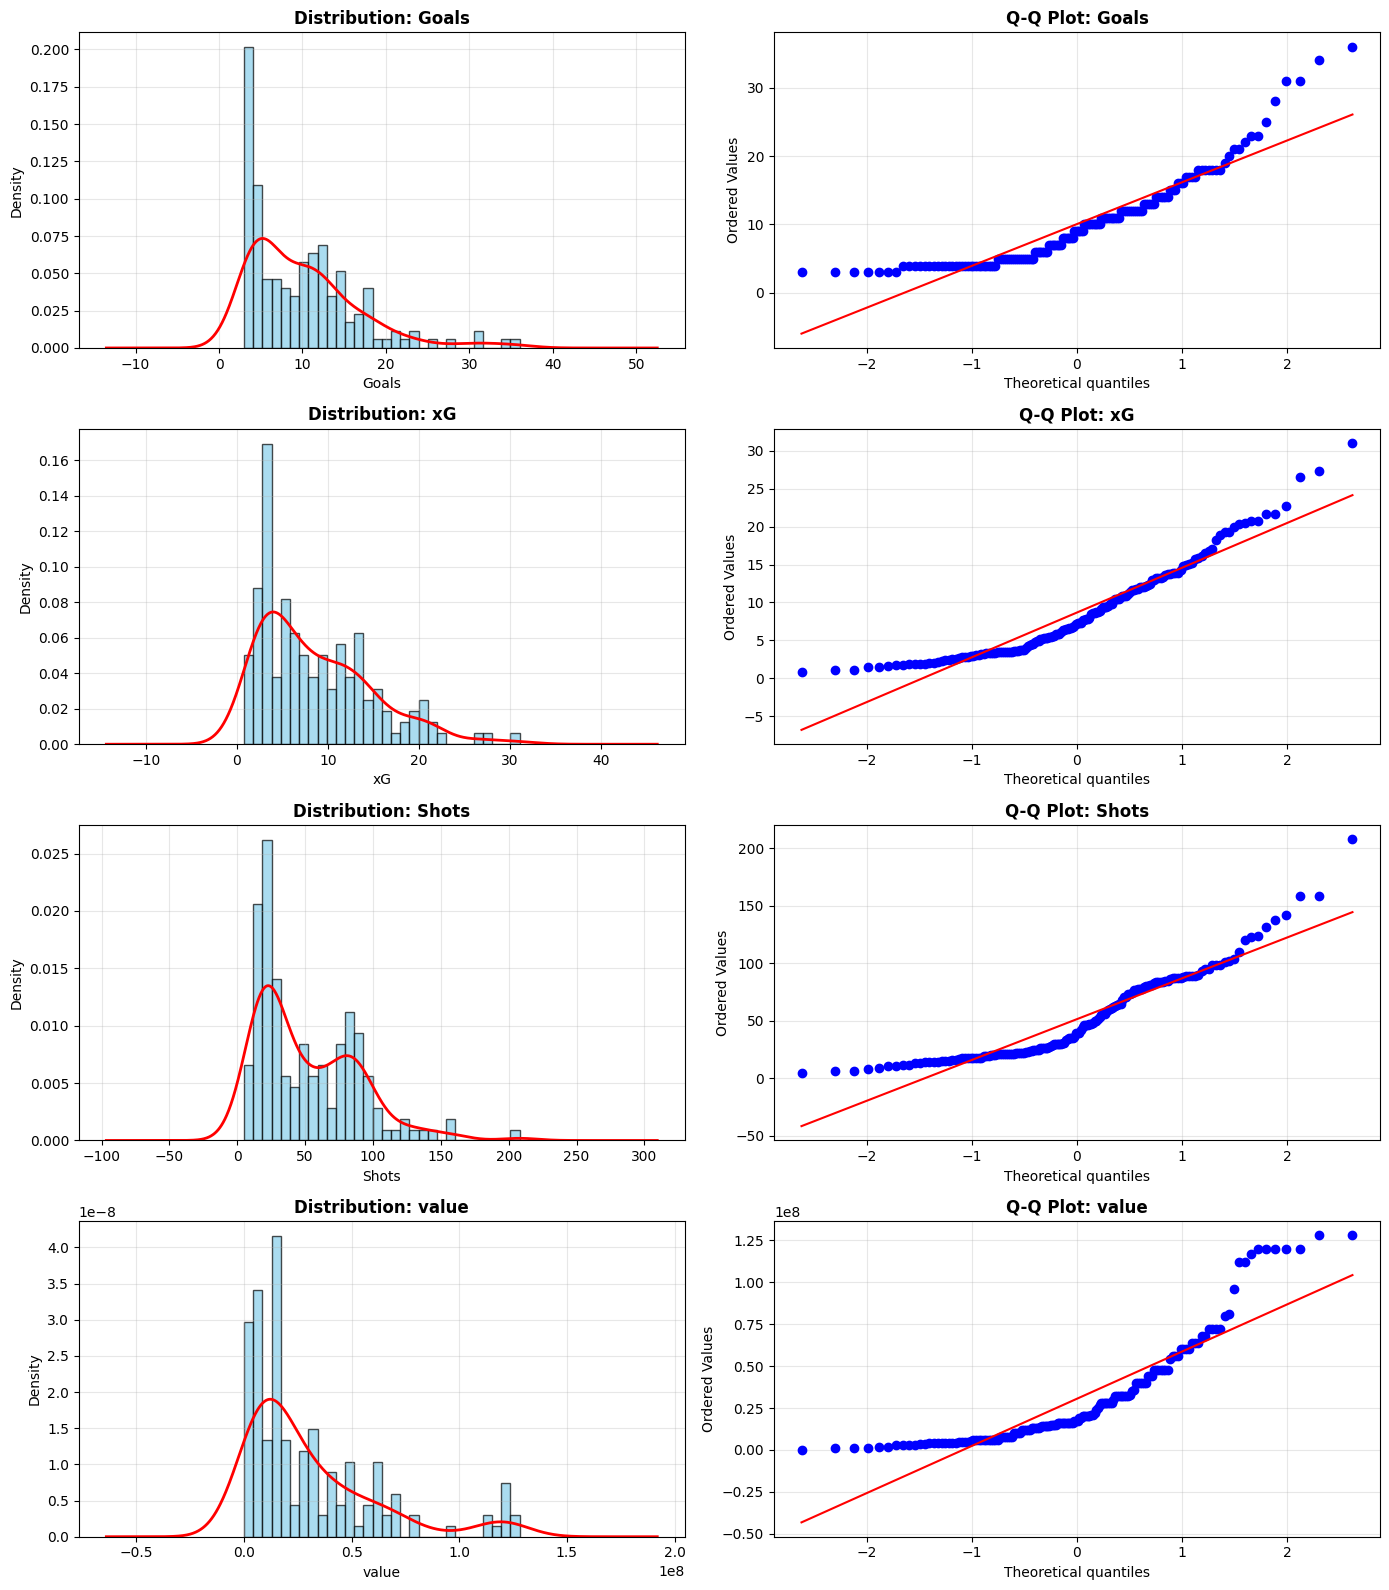

In [52]:
# Visualize key distributions
key_cols = ['Goals', 'xG', 'Shots', 'value']
available = [col for col in key_cols if col in numeric_cols]

if available:
    fig, axes = plt.subplots(len(available), 2, figsize=(14, 4*len(available)))
    
    if len(available) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(available):
        data = df[col].dropna()
        
        # Histogram + KDE
        axes[idx, 0].hist(data, bins=30, alpha=0.7, color='skyblue', 
                         edgecolor='black', density=True)
        data.plot(kind='kde', ax=axes[idx, 0], color='red', linewidth=2)
        axes[idx, 0].set_title(f'Distribution: {col}', fontweight='bold')
        axes[idx, 0].set_xlabel(col)
        axes[idx, 0].grid(alpha=0.3)
        
        # Q-Q Plot
        stats.probplot(data, dist="norm", plot=axes[idx, 1])
        axes[idx, 1].set_title(f'Q-Q Plot: {col}', fontweight='bold')
        axes[idx, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 3.3 Box Plot Analysis

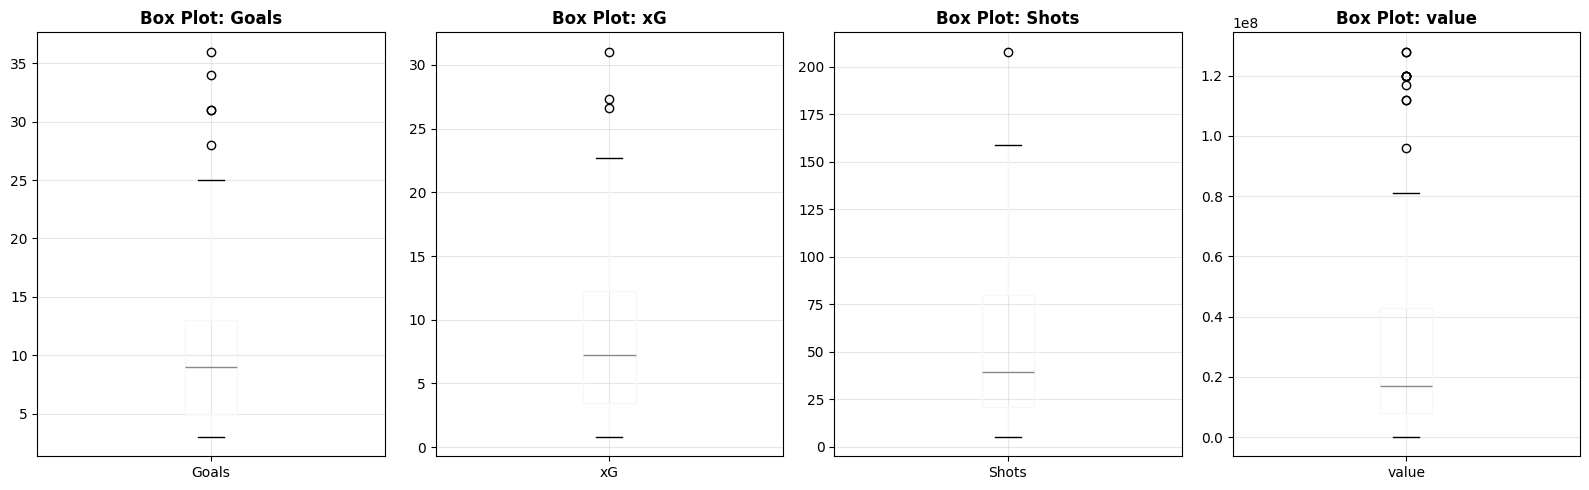


📊 Outlier Analysis:
  • Goals: 5 outliers (3.2%)
  • xG: 3 outliers (1.9%)
  • Shots: 1 outliers (0.6%)
  • value: 11 outliers (7.0%)


In [53]:
# Box plots
if available:
    fig, axes = plt.subplots(1, len(available), figsize=(4*len(available), 5))
    
    if len(available) == 1:
        axes = [axes]
    
    for idx, col in enumerate(available):
        df.boxplot(column=col, ax=axes[idx])
        axes[idx].set_title(f'Box Plot: {col}', fontweight='bold')
        axes[idx].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Outlier analysis
    print("\n📊 Outlier Analysis:")
    for col in available:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
        print(f"  • {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

## 4. Correlation Analysis

### 4.1 Correlation Matrix

In [54]:
# Correlation matrix
corr_matrix = df[numeric_cols].corr()

print("=" * 80)
print("CORRELATION MATRIX (Pearson)")
print("=" * 80)
print(corr_matrix.round(3))

CORRELATION MATRIX (Pearson)
                         Matches_Played  Substitution   Mins  Goals     xG  \
Matches_Played                    1.000         0.123  0.994  0.785  0.817   
Substitution                      0.123         1.000  0.190  0.190  0.204   
Mins                              0.994         0.190  1.000  0.793  0.825   
Goals                             0.785         0.190  0.793  1.000  0.931   
xG                                0.817         0.204  0.825  0.931  1.000   
xG Per Avg Match                 -0.126         0.076 -0.123  0.268  0.348   
Shots                             0.853         0.182  0.861  0.896  0.914   
OnTarget                          0.825         0.190  0.830  0.932  0.937   
Shots Per Avg Match               0.004         0.104  0.008  0.348  0.340   
On Target Per Avg Match          -0.102         0.106 -0.102  0.319  0.294   
Year                             -0.856        -0.361 -0.866 -0.709 -0.731   
value                             0

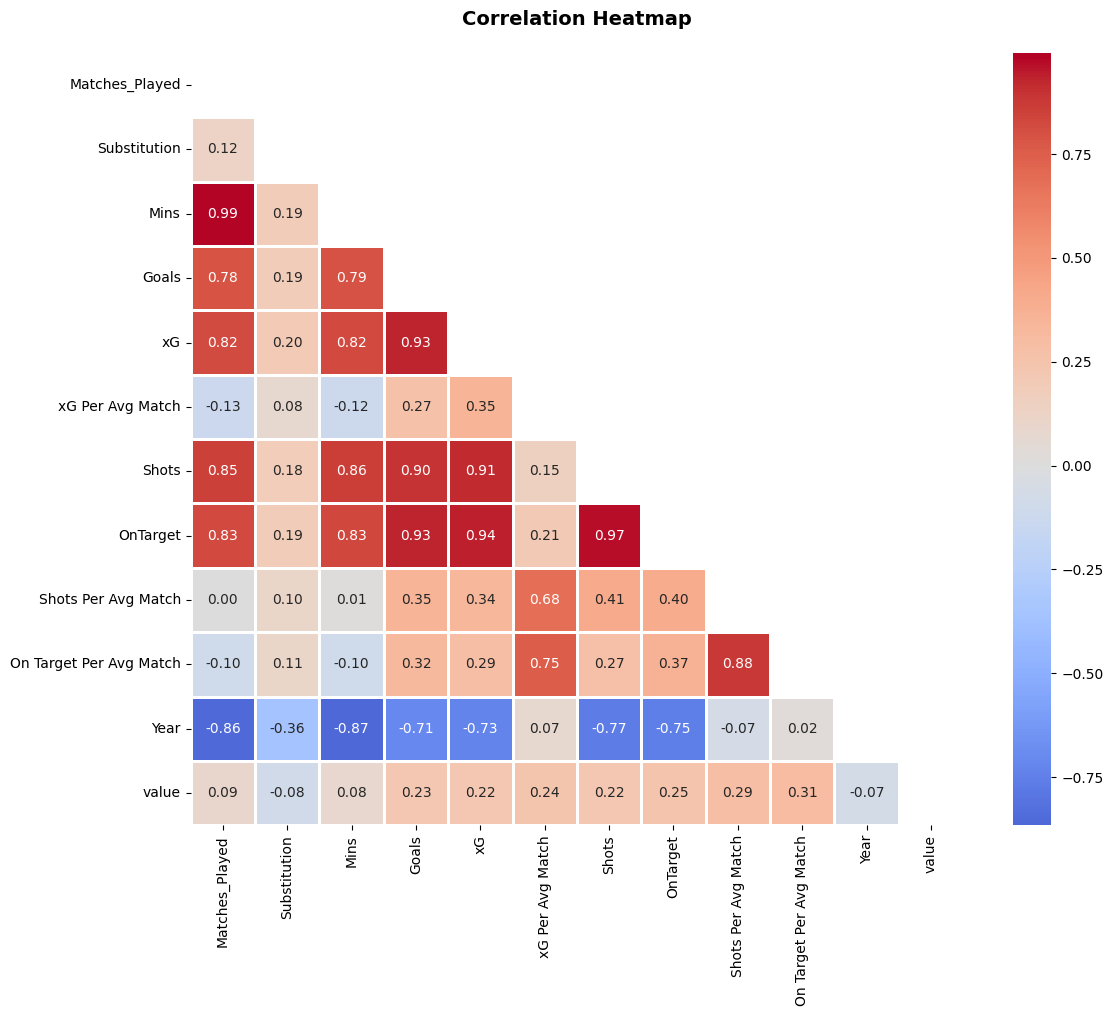


📊 Interpretation:
  • |r| ≥ 0.7: Strong
  • 0.3 ≤ |r| < 0.7: Moderate
  • |r| < 0.3: Weak


In [55]:
# Heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("  • |r| ≥ 0.7: Strong")
print("  • 0.3 ≤ |r| < 0.7: Moderate")
print("  • |r| < 0.3: Weak")

### 4.2 Strong Correlations

In [56]:
# Find strong correlations
print("=" * 80)
print("STRONG CORRELATIONS (|r| > 0.7)")
print("=" * 80)

strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            strong_corr.append({
                'Variable 1': col1,
                'Variable 2': col2,
                'Correlation': round(corr_val, 3)
            })

if strong_corr:
    df_corr = pd.DataFrame(strong_corr).sort_values('Correlation', 
                                                     key=abs, ascending=False)
    print(df_corr.to_string(index=False))
else:
    print("No strong correlations found.")

STRONG CORRELATIONS (|r| > 0.7)
         Variable 1              Variable 2  Correlation
     Matches_Played                    Mins        0.994
              Shots                OnTarget        0.970
                 xG                OnTarget        0.937
              Goals                OnTarget        0.932
              Goals                      xG        0.931
                 xG                   Shots        0.914
              Goals                   Shots        0.896
Shots Per Avg Match On Target Per Avg Match        0.880
               Mins                    Year       -0.866
               Mins                   Shots        0.861
     Matches_Played                    Year       -0.856
     Matches_Played                   Shots        0.853
               Mins                OnTarget        0.830
     Matches_Played                OnTarget        0.825
               Mins                      xG        0.825
     Matches_Played                      xG        0.817

## 5. Statistical Tests

### 5.1 T-Test Example

In [57]:
# Compare Goals between years (if applicable)
if 'Year' in df.columns and 'Goals' in df.columns:
    years = df['Year'].unique()
    
    if len(years) >= 2:
        year1, year2 = sorted(years)[:2]
        
        goals_y1 = df[df['Year'] == year1]['Goals'].dropna()
        goals_y2 = df[df['Year'] == year2]['Goals'].dropna()
        
        print("=" * 80)
        print(f"T-TEST: Goals {year1} vs {year2}")
        print("=" * 80)
        print(f"H0: Mean goals are equal")
        print(f"If p-value < 0.05 → Significant difference\n")
        
        t_stat, p_value = stats.ttest_ind(goals_y1, goals_y2)
        
        print(f"Mean {year1}: {goals_y1.mean():.2f}")
        print(f"Mean {year2}: {goals_y2.mean():.2f}")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"\nSignificant difference")
        else:
            print(f"\nNo significant difference")

T-TEST: Goals 2019 vs 2020
H0: Mean goals are equal
If p-value < 0.05 → Significant difference

Mean 2019: 14.50
Mean 2020: 5.28
T-statistic: 12.5424
P-value: 0.0000

Significant difference


### 5.2 ANOVA Example

In [58]:
# Compare Goals across Leagues
if 'League' in df.columns and 'Goals' in df.columns:
    leagues = df['League'].unique()
    
    if len(leagues) >= 3:
        print("=" * 80)
        print("ANOVA: Goals across Leagues")
        print("=" * 80)
        print("H0: All leagues have same mean")
        print("If p-value < 0.05 → Significant difference\n")
        
        groups = [df[df['League'] == league]['Goals'].dropna() 
                  for league in leagues]
        f_stat, p_value = stats.f_oneway(*groups)
        
        print(f"F-statistic: {f_stat:.4f}")
        print(f"P-value: {p_value:.4f}")
        
        print("\nMean Goals by League:")
        for league in leagues:
            mean = df[df['League'] == league]['Goals'].mean()
            print(f"  • {league}: {mean:.2f}")
        
        if p_value < 0.05:
            print("\nSignificant difference")
        else:
            print("\nNo significant difference")

ANOVA: Goals across Leagues
H0: All leagues have same mean
If p-value < 0.05 → Significant difference

F-statistic: 0.7945
P-value: 0.7477

Mean Goals by League:
  • MLS: 31.00
  • La Liga: 8.89
  • Primeira Liga: 9.33
  • Serie A: 11.00
  • Bundesliga: 10.57
  • France Ligue 7: 12.00
  • France Ligue 13: 6.50
  • France Ligue 6: 12.00
  • France Ligue 15: 6.50
  • France Ligue 9: 11.00
  • France Ligue 20: 5.50
  • France Ligue 12: 9.00
  • France Ligue 2: 13.00
  • France Ligue 19: 8.00
  • France Ligue 14: 6.50
  • France Ligue 17: 6.00
  • France Ligue 10: 7.50
  • France Ligue 16: 6.50
  • France Ligue 5: 9.00
  • France Ligue 4: 13.00
  • Premier League: 11.11
  • Campeonato Brasileiro SÃ©rie A: 10.67
  • Eredivisie: 5.00
  • France Ligue 18: 4.00
  • France Ligue 3: 6.00
  • France Ligue 8: 5.00
  • France Ligue 11: 5.00

No significant difference


## 6. Advanced Analysis

### 6.1 Group Statistics by League

In [59]:
# Group by League
if 'League' in df.columns:
    print("=" * 80)
    print("GROUP STATISTICS BY LEAGUE")
    print("=" * 80)
    
    agg_cols = [col for col in ['Goals', 'xG', 'Shots', 'value'] 
                if col in numeric_cols]
    
    if agg_cols:
        league_stats = df.groupby('League')[agg_cols].agg(
            ['mean', 'median', 'std', 'min', 'max'])
        print(league_stats.round(2))

GROUP STATISTICS BY LEAGUE
                                Goals                          xG         \
                                 mean median   std min max   mean median   
League                                                                     
Bundesliga                      10.57   10.0  6.92   3  34   8.77   8.12   
Campeonato Brasileiro SÃ©rie A  10.67   10.0  1.15  10  12  10.94  10.42   
Eredivisie                       5.00    5.0   NaN   5   5   4.02   4.02   
France Ligue 10                  7.50    7.5  3.54   5  10   6.40   6.40   
France Ligue 11                  5.00    5.0   NaN   5   5   4.75   4.75   
France Ligue 12                  9.00    9.0   NaN   9   9  10.90  10.90   
France Ligue 13                  6.50    6.5  3.54   4   9   4.59   4.59   
France Ligue 14                  6.50    6.5  3.54   4   9   5.84   5.84   
France Ligue 15                  6.50    6.5  3.54   4   9   3.93   3.93   
France Ligue 16                  6.50    6.5  3.54   4   9   

### 6.2 Top Performers

In [60]:
# Top 10 by Goals
if 'Player Names' in df.columns and 'Goals' in df.columns:
    print("=" * 80)
    print("TOP 10 PLAYERS BY GOALS")
    print("=" * 80)
    
    display_cols = ['Player Names', 'League', 'Goals']
    if 'xG' in df.columns:
        display_cols.append('xG')
    if 'Shots' in df.columns:
        display_cols.append('Shots')
    
    top = df.nlargest(10, 'Goals')[display_cols]
    print(top.to_string(index=False))

TOP 10 PLAYERS BY GOALS
      Player Names         League  Goals    xG  Shots
     ciro immobile        Serie A     36 26.61    142
robert lewandowski     Bundesliga     34 31.05    138
zlatan ibrahimovic            MLS     31 22.72    159
 cristiano ronaldo        Serie A     31 27.32    208
       timo werner     Bundesliga     28 20.80    123
      lionel messi        La Liga     25 21.63    159
     romelu lukaku        Serie A     23 18.94     99
       jamie vardy Premier League     23 19.28     89
        danny ings Premier League     22 16.79     93
     karim benzema        La Liga     21 21.61    124


In [61]:
# Top 10 by Market Value
if 'Player Names' in df.columns and 'value' in df.columns:
    print("\n" + "=" * 80)
    print("TOP 10 BY MARKET VALUE")
    print("=" * 80)
    
    top_val = df.nlargest(10, 'value')[
        ['Player Names', 'League', 'value', 'Goals']].copy()
    top_val['Value_M'] = (top_val['value'] / 1e6).round(1)
    top_val = top_val.drop('value', axis=1)
    print(top_val.to_string(index=False))


TOP 10 BY MARKET VALUE
   Player Names         League  Goals  Value_M
         neymar France Ligue 7     12    128.0
raheem sterling Premier League     20    128.0
kevin de bruyne Premier League     13    120.0
  mohamed salah Premier League     19    120.0
     harry kane Premier League     18    120.0
  mohamed salah Premier League      8    120.0
     harry kane Premier League      7    120.0
   jadon sancho     Bundesliga     17    117.0
   lionel messi        La Liga     25    112.0
   lionel messi        La Liga      4    112.0


### 6.3 Efficiency Metrics

In [62]:
# Calculate efficiency
required = ['Goals', 'Shots', 'OnTarget']
if all(col in df.columns for col in required):
    print("=" * 80)
    print("EFFICIENCY METRICS")
    print("=" * 80)
    
    df_eff = df.copy()
    df_eff['Goals_per_Shot'] = (df_eff['Goals'] / df_eff['Shots']).round(3)
    df_eff['Shot_Accuracy'] = (df_eff['OnTarget'] / df_eff['Shots'] * 100).round(2)
    
    if 'Matches_Played' in df.columns:
        df_eff['Goals_per_Match'] = (df_eff['Goals'] / 
                                     df_eff['Matches_Played']).round(3)
    
    # Top efficient players (min 20 shots)
    eff_cols = ['Player Names', 'League', 'Goals_per_Shot', 'Shot_Accuracy']
    if 'Goals_per_Match' in df_eff.columns:
        eff_cols.append('Goals_per_Match')
    
    efficient = df_eff[df_eff['Shots'] >= 20].nlargest(
        10, 'Goals_per_Shot')[eff_cols]
    
    print("Top 10 Most Efficient (min 20 shots):")
    print(efficient.to_string(index=False))

EFFICIENCY METRICS
Top 10 Most Efficient (min 20 shots):
      Player Names         League  Goals_per_Shot  Shot_Accuracy  Goals_per_Match
       jamie vardy Premier League           0.381          71.43            1.000
    erling haaland     Bundesliga           0.353          55.88            1.091
      lucas alario     Bundesliga           0.350          55.00            1.167
robert lewandowski     Bundesliga           0.343          48.57            1.714
      mauro icardi France Ligue 6           0.333          55.56            0.857
    erling haaland     Bundesliga           0.333          46.67            1.429
      jadon sancho     Bundesliga           0.327          53.85            0.680
       boulaye dia France Ligue 2           0.320          48.00            0.889
     romelu lukaku        Serie A           0.318          45.45            1.167
 cristiano ronaldo        Serie A           0.308          50.00            1.600


### 6.4 League Comparison

In [63]:
# Compare leagues
if 'League' in df.columns:
    print("=" * 80)
    print("LEAGUE COMPARISON")
    print("=" * 80)
    
    comparison = df.groupby('League').agg({
        'Player Names': 'count',
        'Goals': 'mean',
        'xG': 'mean',
        'Shots': 'mean',
        'value': 'mean'
    }).round(2)
    
    comparison.columns = ['Players', 'Avg_Goals', 'Avg_xG', 
                          'Avg_Shots', 'Avg_Value_M']
    comparison['Avg_Value_M'] = (comparison['Avg_Value_M'] / 1e6).round(2)
    comparison = comparison.sort_values('Avg_Goals', ascending=False)
    
    print(comparison)

LEAGUE COMPARISON
                                Players  Avg_Goals  Avg_xG  Avg_Shots  \
League                                                                  
MLS                                   1      31.00   22.72     159.00   
France Ligue 2                        2      13.00    9.12      44.50   
France Ligue 4                        1      13.00   14.86      86.00   
France Ligue 7                        1      12.00   15.87      71.00   
France Ligue 6                        1      12.00   12.11      36.00   
Premier League                       27      11.11   10.23      58.48   
France Ligue 9                        1      11.00    7.77      42.00   
Serie A                              38      11.00    8.84      56.71   
Campeonato Brasileiro SÃ©rie A        3      10.67   10.94      59.00   
Bundesliga                           30      10.57    8.77      49.43   
Primeira Liga                         3       9.33    7.22      53.67   
France Ligue 12                  

## 7. Summary

### Key Findings

In [64]:
print("=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset:")
print(f"  • Total players: {len(df)}")
if 'League' in df.columns:
    print(f"  • Leagues: {df['League'].nunique()}")
if 'Year' in df.columns:
    print(f"  • Years: {df['Year'].min()} - {df['Year'].max()}")

if 'Goals' in df.columns:
    print(f"\n⚽ Goals:")
    print(f"  • Average: {df['Goals'].mean():.2f}")
    print(f"  • Max: {df['Goals'].max()}")
    if 'Player Names' in df.columns:
        top_scorer = df.loc[df['Goals'].idxmax(), 'Player Names']
        print(f"  • Top scorer: {top_scorer}")

if 'value' in df.columns:
    print(f"\n💰 Market Value:")
    print(f"  • Average: ${df['value'].mean()/1e6:.2f}M")
    print(f"  • Max: ${df['value'].max()/1e6:.2f}M")

print(f"\n📈 Distributions:")
normal_count = len([r for r in normality_results if 'Normal' in r['Result']])
print(f"  • Normal distributions: {normal_count}/{len(numeric_cols)}")

if strong_corr:
    print(f"\n🔗 Correlations:")
    print(f"  • Strong correlations: {len(strong_corr)}")

print("\n" + "=" * 80)
print("Statistical Analysis Complete!")
print("=" * 80)

KEY FINDINGS SUMMARY

📊 Dataset:
  • Total players: 158
  • Leagues: 27
  • Years: 2019 - 2020

⚽ Goals:
  • Average: 10.06
  • Max: 36
  • Top scorer: ciro immobile

💰 Market Value:
  • Average: $30.56M
  • Max: $128.00M

📈 Distributions:
  • Normal distributions: 12/12

🔗 Correlations:
  • Strong correlations: 23

Statistical Analysis Complete!
